In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### import data

In [2]:
df = pd.read_csv(r"C:\Users\Anish Kumar\Downloads\large_sales.csv")

In [3]:
df.head(5)

,Order_ID,Order_Date,City,Product,Category,Channel,Customer_Segment,Payment_Method,Quantity,Unit_Price,...,Sales,Cost,Profit,Profit_Margin_Pct,Month,Month_Name,Quarter,Year,Day_Name,Weekend
0,ORD0097384,2024-01-01,Bengaluru,Tablet,Office,Store,Consumer,Debit Card,1,43384.87,...,35041.96,23400.29,11641.67,33.22,1,January,Q1,2024,Monday,No
1,ORD0054822,2024-01-01,Bengaluru,Headphones,Accessories,Marketplace,Home Office,Debit Card,7,35564.72,...,247832.75,181138.97,66693.78,26.91,1,January,Q1,2024,Monday,No
2,ORD0006567,2024-01-01,Hyderabad,Headphones,Office,Marketplace,Corporate,UPI,6,98829.18,...,529941.83,315728.84,214212.99,40.42,1,January,Q1,2024,Monday,No
3,ORD0037082,2024-01-01,Bengaluru,Monitor,Accessories,Marketplace,Consumer,UPI,4,12506.66,...,46940.00,30202.41,16737.59,35.66,1,January,Q1,2024,Monday,No
4,ORD0076597,2024-01-01,Kolkata,Mouse,Electronics,Online,Corporate,Debit Card,3,73625.86,...,168087.84,129593.53,38494.31,22.90,1,January,Q1,2024,Monday,No


In [4]:
df.tail(5)

,Order_ID,Order_Date,City,Product,Category,Channel,Customer_Segment,Payment_Method,Quantity,Unit_Price,...,Sales,Cost,Profit,Profit_Margin_Pct,Month,Month_Name,Quarter,Year,Day_Name,Weekend
99995,ORD0084825,2025-12-31,Delhi,Keyboard,Accessories,Store,Corporate,UPI,1,116767.52,...,90553.21,64568.50,25984.71,28.70,12,December,Q4,2025,Wednesday,No
99996,ORD0031111,2025-12-31,Pune,Tablet,Office,Marketplace,Consumer,Debit Card,3,112068.10,...,314519.12,238568.44,75950.68,24.15,12,December,Q4,2025,Wednesday,No
99997,ORD0067132,2025-12-31,Hyderabad,Headphones,Electronics,Store,Home Office,Credit Card,5,14379.50,...,63161.95,49297.27,13864.68,21.95,12,December,Q4,2025,Wednesday,No
99998,ORD0056816,2025-12-31,Kolkata,Printer,Accessories,Online,Home Office,Net Banking,2,54367.81,...,84879.02,53897.89,30981.13,36.50,12,December,Q4,2025,Wednesday,No
99999,ORD0023522,2025-12-31,Mumbai,Laptop,Office,Store,Consumer,Credit Card,3,3355.02,...,9774.18,8544.38,1229.80,12.58,12,December,Q4,2025,Wednesday,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Order_ID           100000 non-null  str    
 1   Order_Date         100000 non-null  str    
 2   City               100000 non-null  str    
 3   Product            100000 non-null  str    
 4   Category           100000 non-null  str    
 5   Channel            100000 non-null  str    
 6   Customer_Segment   100000 non-null  str    
 7   Payment_Method     99700 non-null   str    
 8   Quantity           100000 non-null  int64  
 9   Unit_Price         100000 non-null  float64
 10  Discount_Pct       99500 non-null   float64
 11  Customer_Age       100000 non-null  int64  
 12  Customer_Rating    99000 non-null   float64
 13  Gross_Sales        100000 non-null  float64
 14  Discount_Amount    100000 non-null  float64
 15  Sales              100000 non-null  float64
 16  Cost          

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'City', 'Product', 'Category', 'Channel',
       'Customer_Segment', 'Payment_Method', 'Quantity', 'Unit_Price',
       'Discount_Pct', 'Customer_Age', 'Customer_Rating', 'Gross_Sales',
       'Discount_Amount', 'Sales', 'Cost', 'Profit', 'Profit_Margin_Pct',
       'Month', 'Month_Name', 'Quarter', 'Year', 'Day_Name', 'Weekend'],
      dtype='str')

In [7]:
df.isnull().sum()

Order_ID                0
Order_Date              0
City                    0
Product                 0
Category                0
Channel                 0
Customer_Segment        0
Payment_Method        300
Quantity                0
Unit_Price              0
Discount_Pct          500
Customer_Age            0
Customer_Rating      1000
Gross_Sales             0
Discount_Amount         0
Sales                   0
Cost                    0
Profit                  0
Profit_Margin_Pct       0
Month                   0
Month_Name              0
Quarter                 0
Year                    0
Day_Name                0
Weekend                 0
dtype: int64

### Fill The Payment_Method Value

In [8]:
df["Payment_Method"].unique()

<StringArray>
['Debit Card', 'UPI', 'Cash', 'Credit Card', 'Net Banking', nan]
Length: 6, dtype: str

In [9]:
df["Payment_Method"] = df["Payment_Method"].fillna(
    df["Payment_Method"].mode()[0]
)

### ### Fill The Discount_Pct Value

In [10]:
df["Discount_Pct"]

0        19.23
1         0.45
2        10.63
3         6.17
4        23.90
         ...  
99995    22.45
99996     6.45
99997    12.15
99998    21.94
99999     2.89
Name: Discount_Pct, Length: 100000, dtype: float64

In [11]:
df["Discount_Pct"] = df["Discount_Pct"].fillna(
    df["Discount_Pct"].median()
)

### Fill The Customer_Rating Value

In [12]:
df["Customer_Rating"]

0        1.6
1        2.6
2        1.3
3        1.9
4        2.1
        ... 
99995    2.1
99996    4.4
99997    3.4
99998    4.1
99999    2.7
Name: Customer_Rating, Length: 100000, dtype: float64

In [13]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(
    df["Customer_Rating"].median()
)

In [14]:
df.isna().sum()

Order_ID             0
Order_Date           0
City                 0
Product              0
Category             0
Channel              0
Customer_Segment     0
Payment_Method       0
Quantity             0
Unit_Price           0
Discount_Pct         0
Customer_Age         0
Customer_Rating      0
Gross_Sales          0
Discount_Amount      0
Sales                0
Cost                 0
Profit               0
Profit_Margin_Pct    0
Month                0
Month_Name           0
Quarter              0
Year                 0
Day_Name             0
Weekend              0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Order_ID           100000 non-null  str    
 1   Order_Date         100000 non-null  str    
 2   City               100000 non-null  str    
 3   Product            100000 non-null  str    
 4   Category           100000 non-null  str    
 5   Channel            100000 non-null  str    
 6   Customer_Segment   100000 non-null  str    
 7   Payment_Method     100000 non-null  str    
 8   Quantity           100000 non-null  int64  
 9   Unit_Price         100000 non-null  float64
 10  Discount_Pct       100000 non-null  float64
 11  Customer_Age       100000 non-null  int64  
 12  Customer_Rating    100000 non-null  float64
 13  Gross_Sales        100000 non-null  float64
 14  Discount_Amount    100000 non-null  float64
 15  Sales              100000 non-null  float64
 16  Cost          

In [16]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Order_ID           100000 non-null  str           
 1   Order_Date         100000 non-null  datetime64[us]
 2   City               100000 non-null  str           
 3   Product            100000 non-null  str           
 4   Category           100000 non-null  str           
 5   Channel            100000 non-null  str           
 6   Customer_Segment   100000 non-null  str           
 7   Payment_Method     100000 non-null  str           
 8   Quantity           100000 non-null  int64         
 9   Unit_Price         100000 non-null  float64       
 10  Discount_Pct       100000 non-null  float64       
 11  Customer_Age       100000 non-null  int64         
 12  Customer_Rating    100000 non-null  float64       
 13  Gross_Sales        100000 non-null  float64       
 14  

## Bar Chart 

1. Calculate the total Sales for each City and create a bar chart.

In [18]:
Total_Sales = df.groupby("City")["Sales"].sum().round(2)
Total_Sales

City
Bengaluru    2.577070e+09
Chennai      2.657385e+09
Delhi        2.549211e+09
Hyderabad    2.539507e+09
Jaipur       2.547586e+09
Kolkata      2.557086e+09
Mumbai       2.590720e+09
Pune         2.564498e+09
Name: Sales, dtype: float64

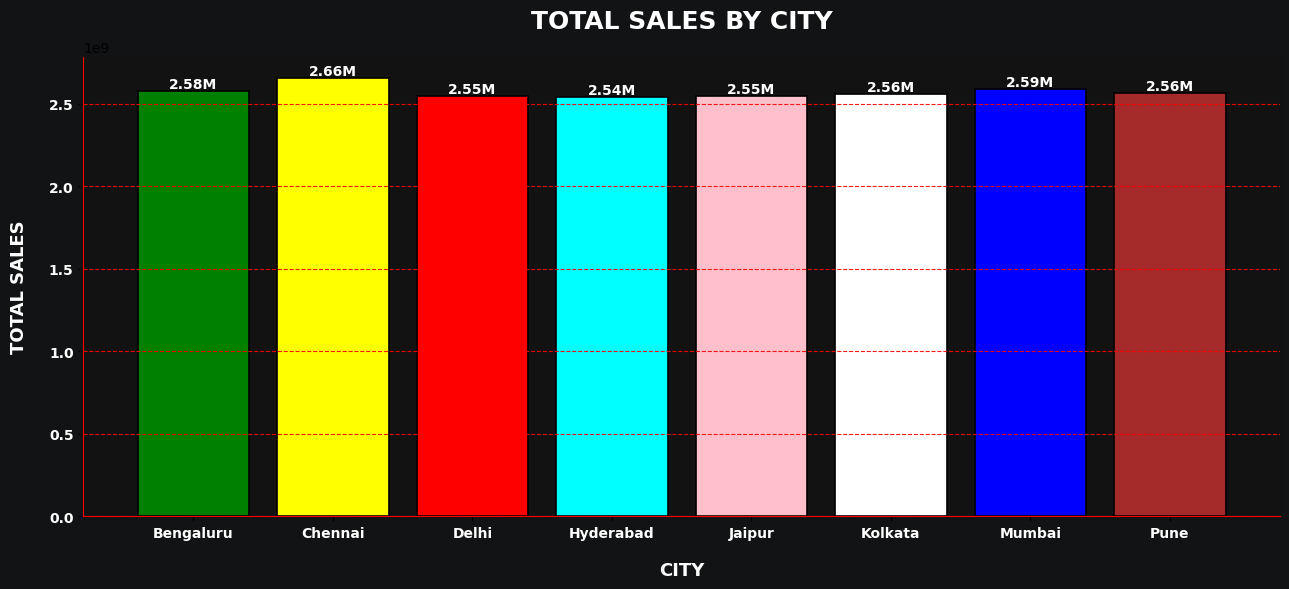

In [19]:
plt.figure(figsize=(13, 6), facecolor="#121314", dpi=100)

bars = plt.bar(
    Total_Sales.index,
    Total_Sales.values,
    edgecolor="black",
    color=["green", "Yellow", "red", "cyan", "pink", "white", "blue", "brown"],
    linewidth=1.2
)

plt.title(
    "TOTAL SALES BY CITY",
    pad=20,
    color="white",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "CITY",
    color="white",
    fontsize=13,
    fontweight="bold",
    labelpad=15
)

plt.ylabel(
    "TOTAL SALES", 
    color="White",
    fontsize=13,
    fontweight="bold",
    labelpad=15
)

plt.xticks(
    color="white",
    fontsize=10,
    fontweight="bold",
)

plt.yticks(
    color="white",
    fontsize=10,
    fontweight="bold",
)

for bar in bars:
    values = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        values + 1,
        f"{values / 1e9:.2f}M",
        fontsize=10,
        ha="center",
        va="bottom",
        fontweight="bold",
        color="white"
    )
    
plt.gca().set_facecolor("#121212")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.9,
    color="red"
)

plt.tight_layout()

plt.gca().spines["top"].set_color("#121212")
plt.gca().spines["bottom"].set_color("red")
plt.gca().spines["left"].set_color("red")
plt.gca().spines["right"].set_color("#121212")

plt.show()

2. Calculate the total Profit for each Category and create a bar chart.

In [20]:
Total_Profit = df.groupby("Category")["Profit"].sum().round(2)


In [21]:
Total_Profit

Category
Accessories    1.881018e+09
Electronics    1.898753e+09
Office         1.887804e+09
Name: Profit, dtype: float64

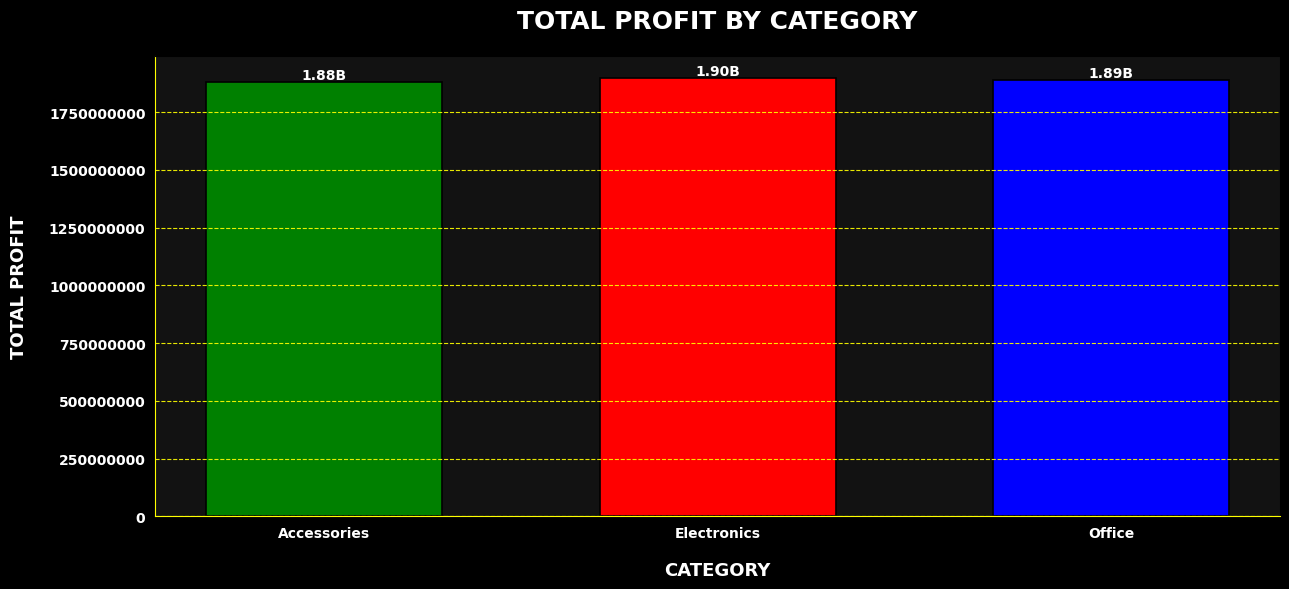

In [22]:
plt.figure(figsize=(13,6), dpi=100, facecolor="black")

bars = plt.bar(
    Total_Profit.index,
    Total_Profit.values,
    edgecolor="black",
    color=["green", "red", "blue"],
    linewidth=1.2,
    width=0.6
)

plt.gca().set_facecolor("#121212")

plt.title(
    "TOTAL PROFIT BY CATEGORY",
    pad=20,
    color="white",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "CATEGORY",
    color="white",
    fontsize=13,
    fontweight="bold",
    labelpad=15
)

plt.ylabel(
    "TOTAL PROFIT", 
    color="White",
    fontsize=13,
    fontweight="bold",
    labelpad=15
)

plt.xticks(
    color="white",
    fontsize=10,
    fontweight="bold",
)

plt.yticks(
    color="white",
    fontsize=10,
    fontweight="bold",
)

for bar in bars:
    values = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        values + 5,
        f"{values / 1e9:.2f}B",
        fontsize=10,
        ha="center",
        va="bottom",
        fontweight="bold",
        color="white"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.9,
    color="yellow"
)

plt.ticklabel_format(axis="y", style="plain")

plt.tight_layout()

plt.gca().spines["top"].set_color("black")
plt.gca().spines["bottom"].set_color("yellow")
plt.gca().spines["left"].set_color("yellow")
plt.gca().spines["right"].set_color("black")

plt.show()

3. Calculate the average Customer Rating for each City.

In [23]:
# Average Customer Rating
Avg_Customer = (
    df.groupby("City")["Customer_Rating"]
      .mean()
      .round(2)
)
Avg_Customer

City
Bengaluru    3.00
Chennai      3.01
Delhi        3.01
Hyderabad    3.01
Jaipur       3.01
Kolkata      3.00
Mumbai       3.01
Pune         3.01
Name: Customer_Rating, dtype: float64

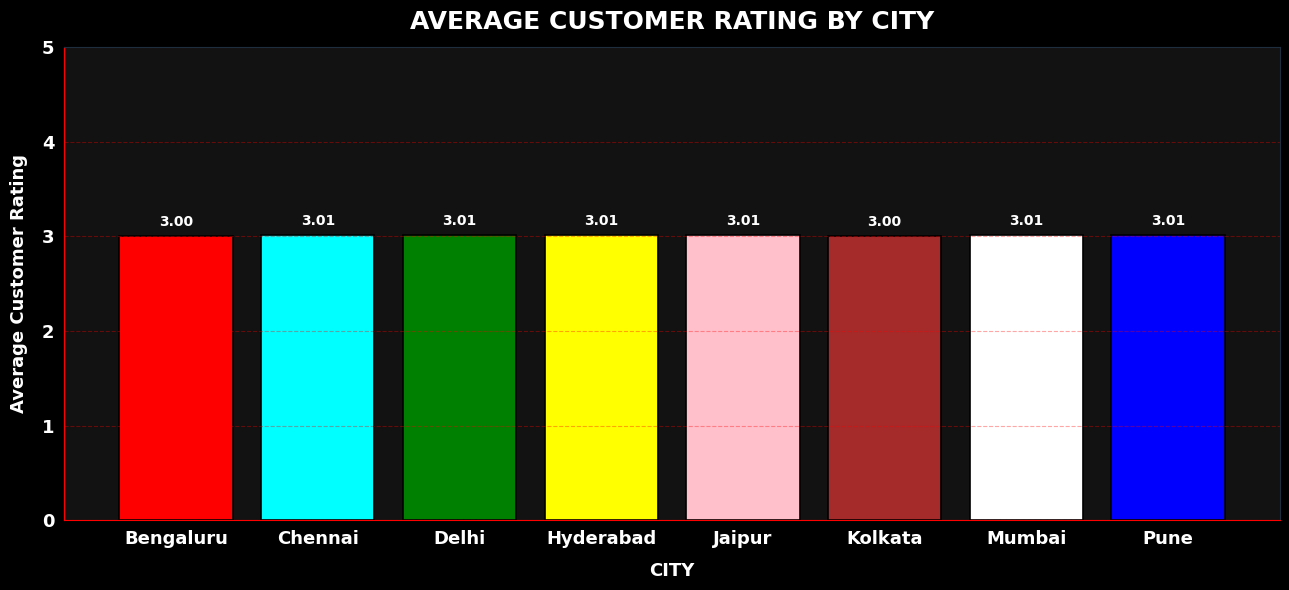

In [24]:
plt.figure(figsize=(13, 6), dpi=100, facecolor="black")

bars = plt.bar(
    Avg_Customer.index,
    Avg_Customer.values,
    color=[
        "red", "cyan", "green", "yellow",
        "pink", "brown", "white", "blue"
    ],
    edgecolor="black",
    linewidth=1.2
)

# Background
plt.gca().set_facecolor("#121212")

# Title
plt.title(
    "AVERAGE CUSTOMER RATING BY CITY",
    color="white",
    pad=13,
    fontsize=18,
    fontweight="bold"
)

# X-axis
plt.xlabel(
    "CITY",
    color="white",
    labelpad=10,
    fontsize=13,
    fontweight="bold"
)

# Y-axis
plt.ylabel(
    "Average Customer Rating",
    color="white",
    labelpad=10,
    fontsize=13,
    fontweight="bold"
)

# X ticks
plt.xticks(
    color="white",
    fontsize=13,
    fontweight="bold"
)

# Y ticks
plt.yticks(
    color="white",
    fontsize=13,
    fontweight="bold"
)

# Grid
plt.grid(
    axis="y",
    color="red",
    alpha=0.35,
    linestyle="--",
    linewidth=0.8
)

# Rating scale
plt.ylim(0, 5)

# Spines
plt.gca().spines["left"].set_color("red")
plt.gca().spines["bottom"].set_color("red")
plt.gca().spines["top"].set_color("#1E2E3F")
plt.gca().spines["right"].set_color("#1E2E3F")

# Data Labels
for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.08,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white"
    )
    
plt.ticklabel_format(axis="y", style="plain")

plt.tight_layout()

plt.show()

4. Calculate the total Quantity sold for each Product.

5. Calculate the average Profit Margin (%) for each Customer Segment.

## Horizontal Bar

1. Create a horizontal bar chart showing total Sales by City.

In [25]:

Total_Sales =(
    df.groupby("City")["Sales"]
        .sum()
        .round(2)
)
Total_Sales 

City
Bengaluru    2.577070e+09
Chennai      2.657385e+09
Delhi        2.549211e+09
Hyderabad    2.539507e+09
Jaipur       2.547586e+09
Kolkata      2.557086e+09
Mumbai       2.590720e+09
Pune         2.564498e+09
Name: Sales, dtype: float64

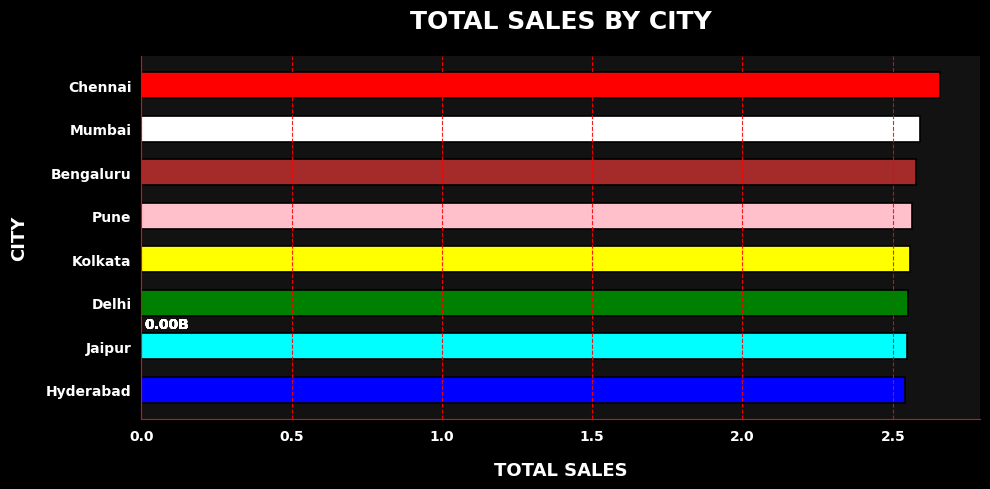

In [26]:
Total_Sales = Total_Sales.sort_values(ascending=True)

plt.figure(figsize=(10, 5), facecolor="black", dpi=100)

barh = plt.barh(
    Total_Sales.index,
    Total_Sales.values,
    color=[
        "blue", "cyan", "green", "yellow",
        "pink", "brown", "white", "red"
    ],
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

plt.gca().set_facecolor("#121212")

plt.title(
    "TOTAL SALES BY CITY",
    color="white",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "TOTAL SALES",
    color="white",
    fontsize=13,
    fontweight="bold",
    labelpad=13
)

plt.ylabel(
    "CITY",
    color="white",
    fontsize=13,
    labelpad=13,
    fontweight="bold"
)

plt.xticks(
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.yticks(
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.9,
    color="red"
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.01e9,
        bar.get_y() + bar.get_height() / 2,
        f"{value / 1e9:.2f}B",
        ha="left",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["left"].set_color("red")
plt.gca().spines["bottom"].set_color("red")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

2. Profit ke according Top 10 Products identify karo.

In [27]:
Product_Sales =( 
    df.groupby("Product")["Profit"]
        .sum()
        .round(2)
        .sort_values(ascending=False)
        .head(10)
)
Product_Sales

Product
Mobile        7.165926e+08
Mouse         7.154079e+08
Laptop        7.135165e+08
Printer       7.123611e+08
Keyboard      7.095527e+08
Tablet        7.054266e+08
Monitor       6.988104e+08
Headphones    6.959069e+08
Name: Profit, dtype: float64

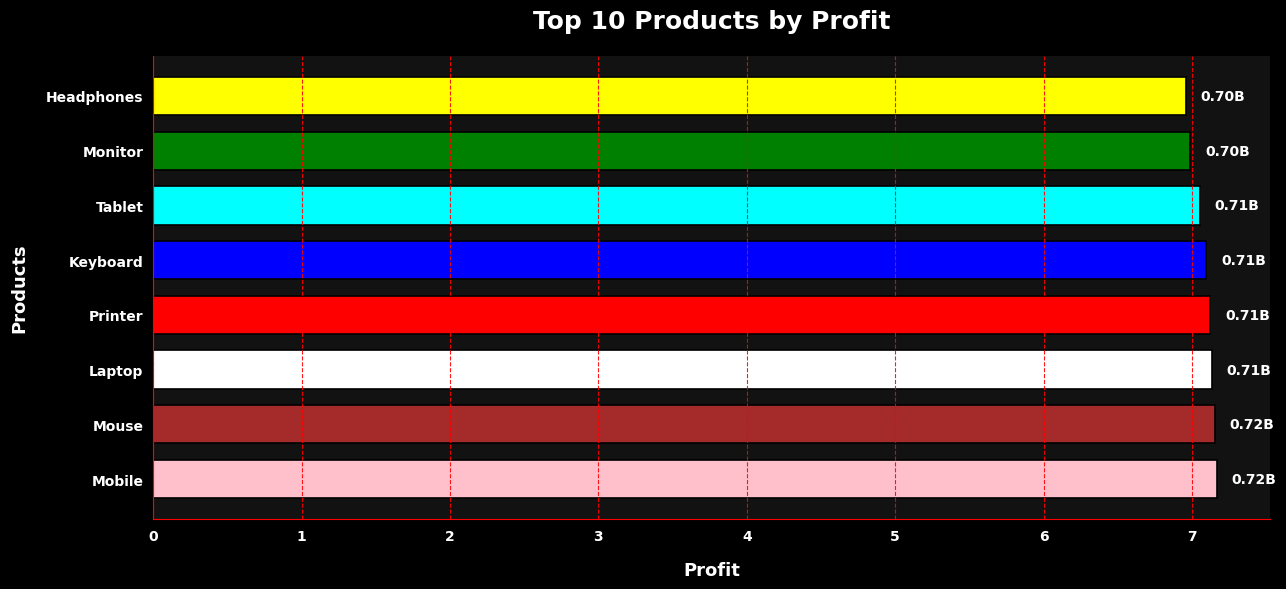

In [28]:

plt.figure(figsize=(13,6), dpi=100, facecolor="black")
bars = plt.barh(
    Product_Sales.index,
    Product_Sales.values,
    color=[
        "pink", "brown", "white", "red",
        "blue", "cyan", "green", "yellow"
    ],
    edgecolor="black",
    height=0.7,
    linewidth=1.2
)

plt.title(
    "Top 10 Products by Profit",
    color="white",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Profit",
    color="white",
    fontsize=13,
    fontweight="bold",
    labelpad=13
)

plt.ylabel(
    "Products",
    color="white",
    fontsize=13,
    labelpad=13,
    fontweight="bold"
)

plt.xticks(
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.yticks(
    color="white",
    fontsize=10,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.9,
    color="red"
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.01e9,
        bar.get_y() + bar.get_height() / 2,
        f"{value / 1e9:.2f}B",
        ha="left",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["left"].set_color("red")
plt.gca().spines["bottom"].set_color("red")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()


plt.gca().set_facecolor("#121212")
plt.show()

## Grouped Bar
- Compare total Quantity by Category across different Cities using a grouped bar chart.

In [32]:
city_category = df.pivot_table(
    index="City",
    columns="Category",
    values="Quantity",
    aggfunc="sum"
)
city_category

Category,Accessories,Electronics,Office
City,,,
Bengaluru,16626,16454,16812
Chennai,17218,16918,16977
Delhi,17028,16543,16666
Hyderabad,16795,16492,16336
Jaipur,16077,17117,16453
Kolkata,16386,16320,16858
Mumbai,16304,16885,16854
Pune,16356,16953,16896


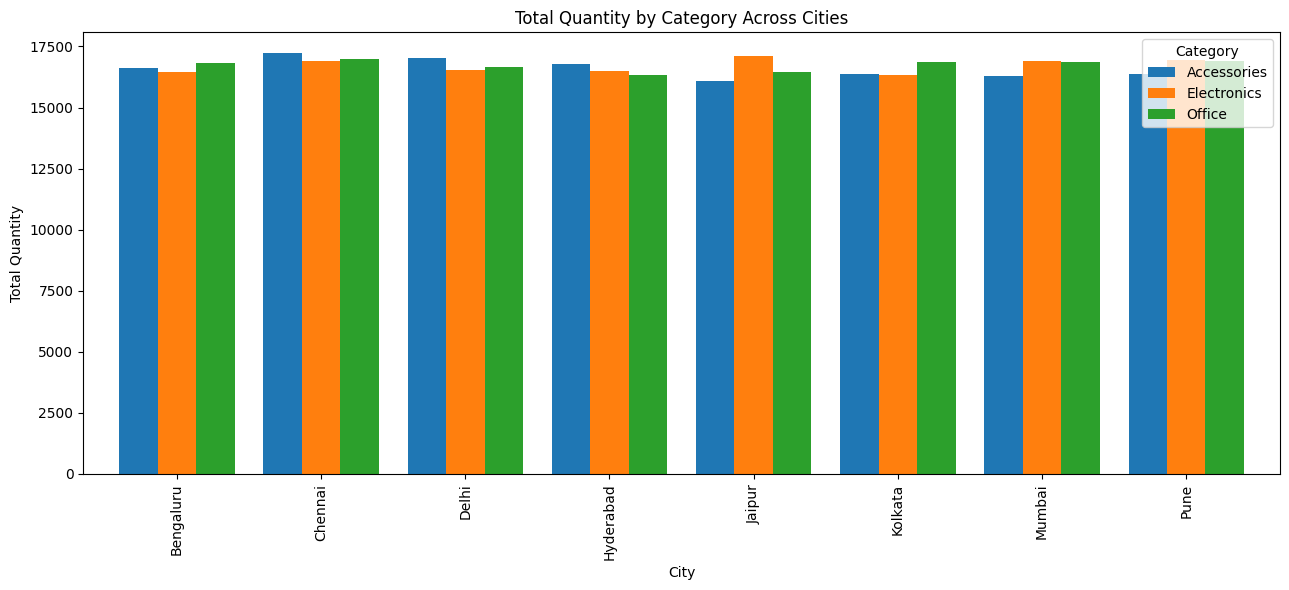

In [47]:
city_category.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8
)

plt.title("Total Quantity by Category Across Cities")
plt.xlabel("City")
plt.ylabel("Total Quantity")

plt.legend(title="Category")


plt.tight_layout()
plt.show()

## Stacked Bar 
- Create a stacked bar chart showing Category-wise Quantity for each Quarter.

## Line Chart 
- Create a line chart showing the monthly trend of total Quantity.

## Multiple Line
- Compare the monthly Quantity trend for each Channel using multiple lines.

Pie Chart: 
- Show the percentage contribution of each Category to total Quantity using a pie chart.
Donut Chart: 
- Show the Profit contribution of each Customer Segment using a donut chart.
Scatter Plot: 
- Create a scatter plot to analyze the relationship between Quantity and Profit.
Histogram: 
- Create a histogram to visualize the distribution of Customer Age.
Box Plot: 
- Create a box plot to compare the Profit distribution across Categories and identify outliers.
Violin Plot: 
- Create a violin plot to compare the Customer Rating distribution across Customer Segments.
Area Chart: 
- Create an area chart showing the monthly Quantity trend.
Stacked Area Chart: 
- Create a stacked area chart showing Category-wise Quantity changes over different months.
Heatmap: 
- Create a correlation heatmap for Quantity, Unit Price, Discount %, Customer Age, Customer Rating, Cost, Profit, and Profit Margin %.
Bubble Chart: 
- Create a bubble chart showing Unit Price vs Profit, with Quantity represented by bubble size.
Error Bar Chart: 
- Calculate the average Customer Rating and standard deviation for each Category, then create an error bar chart.
Step Chart: 
- Create a step chart showing the monthly average Discount %.
ECDF Plot: 
- Create an ECDF plot to visualize the distribution of Profit.
Hexbin Plot: 
- Create a hexbin plot to visualize the density relationship between Unit Price and Quantity.
Bar Chart: 
- Compare the average Customer Rating across different Payment Methods.
Line Chart: 
- Create a line chart showing the quarterly average Profit trend across years.
Scatter Plot: 
- Analyze the relationship between Discount % and Profit Margin % using a scatter plot.
Box Plot: 
- Compare the Profit Margin % distribution across different Channels using a box plot.
Heatmap:
- Create a heatmap showing City × Category total Quantity.

## 🥧 Pie Chart
Q1: Create a pie chart showing total Sales by Category.

In [50]:
Category_Sales = df.groupby("Category")["Sales"].sum().round(2)
Category_Sales

Category
Accessories    6.834900e+09
Electronics    6.899905e+09
Office         6.848259e+09
Name: Sales, dtype: float64

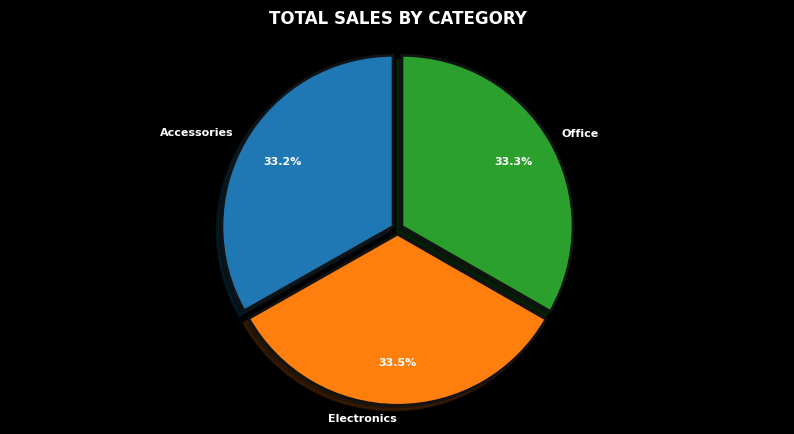

In [105]:
plt.figure(figsize=(10, 5), facecolor="black", dpi=100)
pie_chart = plt.pie(
    Category_Sales.values,
    labels = Category_Sales.index,   
    autopct="%1.1f%%",
    explode=[0.03] * len(Category_Sales),
    shadow=True,
    radius = 1,
    textprops={
        "color":"white",
        "fontweight":"bold",
        "fontsize":8
    },
    startangle=90,
    wedgeprops={
        "edgecolor": "#121314",
        "linewidth": 2
    },
    pctdistance=0.75,
    labeldistance=1.08,
)

plt.title(
    "TOTAL SALES BY CATEGORY",
    color="White",
    fontweight="bold",
    fontsize=12,
    pad=10
)

plt.axis("equal")

plt.show()

## 🍩 Donut Chart
Q2: Create a donut chart showing total Sales by City.

In [92]:
City_Sales = df.groupby("City")["Sales"].sum()

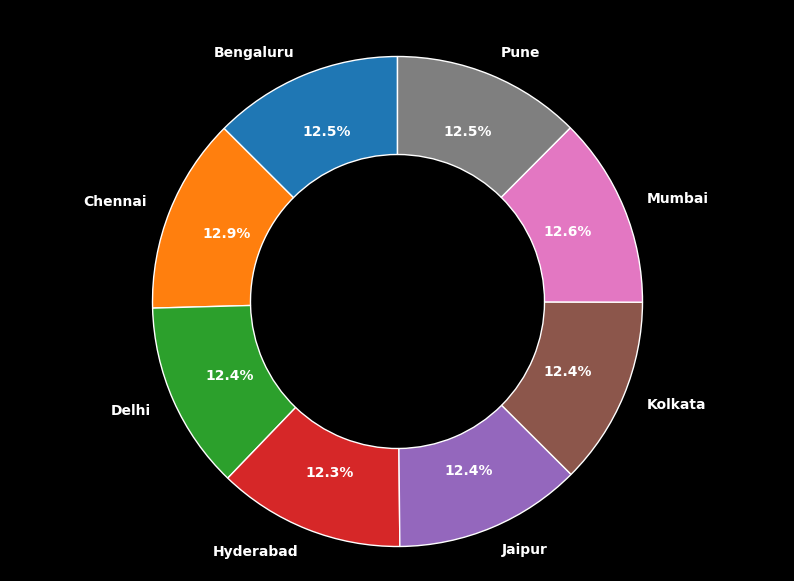

In [104]:
plt.figure(figsize=(10, 7), dpi=100, facecolor="black")

plt.pie(
    City_Sales.values,
    labels=City_Sales.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white"
    }, 
    textprops={
        "color":"white",
        "fontweight":"bold",
        "fontsize":10
    } 
)

plt.title("Total Sales by City")
plt.axis("equal")
plt.show()